In [2]:
import numpy as np
import pandas as pd

In [3]:
df=pd.read_csv("placement.csv")

In [4]:
df.sample(10)

,cgpa,iq,placement
9,8.7,135,1
53,5.7,87,0
42,8.5,134,1
43,5.8,86,0
58,7.2,111,1
7,7.3,115,1
59,8.3,130,1
78,7.3,112,1
94,5.5,81,0
56,8.8,141,1


### here you follow these steps


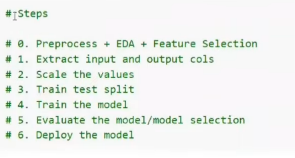 

In [5]:
#### lets see how our data looks like


In [6]:
import matplotlib.pyplot as plt

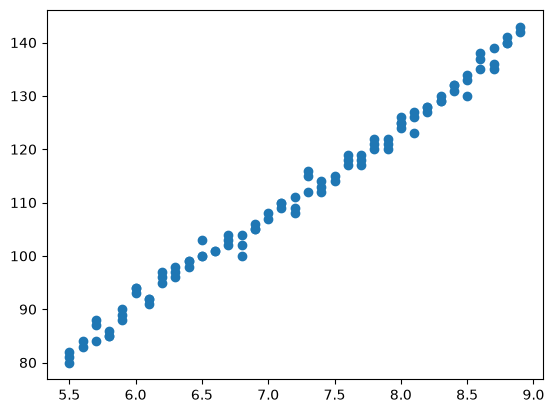

In [7]:
plt.scatter(df['cgpa'],df['iq'])

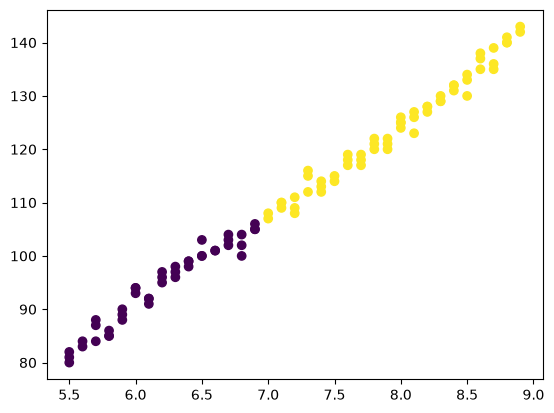

In [8]:
plt.scatter(df['cgpa'],df['iq'],c=df['placement'])

as we can see above the output is true in yellow line  so we can easily draw an line at 7.0 on x axis which classify placement or not so we use logistic regression 

In [9]:
df.sample(5)

,cgpa,iq,placement
49,8.1,123,1
96,7.7,117,1
1,7.8,120,1
15,8.8,140,1
8,5.8,85,0


here cgpa  and iq are independet variable but  placement are dependent 

lets separte both dependent and independent

### lets extract input and output col

In [10]:

x=df.iloc[: ,0:2]

In [11]:
x.head()

,cgpa,iq
0,6.2,95
1,7.8,120
2,8.5,130
3,5.9,90
4,7.1,110


In [12]:
y=df.iloc[:,2:]
y.head()

,placement
0,0
1,1
2,1
3,0
4,1


In [13]:
pd.reset_option('display.max_row') # as iske pahle sare data dikh rhe the usi ko default set karne ke liyeb


In [14]:
y

,placement
0,0
1,1
2,1
3,0
4,1
...,...
96,1
97,1
98,0
99,1


### split train and test set


In [15]:
from sklearn.model_selection import train_test_split

In [16]:
train_test_split(x,y,test_size=0.1) 

[    cgpa   iq
 19   8.4  132
 63   8.6  137
 73   5.8   85
 47   6.1   91
 72   8.5  133
 ..   ...  ...
 91   6.0   94
 93   8.3  129
 64   6.4   99
 37   5.9   89
 11   7.6  118
 
 [90 rows x 2 columns],
     cgpa   iq
 69   8.2  128
 87   5.7   84
 71   7.5  115
 43   5.8   86
 44   6.5  103
 61   6.7  102
 95   6.7  103
 74   6.6  101
 79   8.4  132
 2    8.5  130
 42   8.5  134,
     placement
 19          1
 63          1
 73          0
 47          0
 72          1
 ..        ...
 91          0
 93          1
 64          0
 37          0
 11          1
 
 [90 rows x 1 columns],
     placement
 69          1
 87          0
 71          1
 43          0
 44          0
 61          0
 95          0
 74          0
 79          1
 2           1
 42          1]

as we see above it give 4 output so we will store it in 4 diffent variable

In [17]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.1)


### now we scalled the data


scalling is done to minimze the difference as we see our cgpa vary between (0-10)  but iq is (80-150)  so the distannce between both the column is big so by scalling we transform the data btween (-1 to 1)

In [18]:

from sklearn.preprocessing import StandardScaler
# now create an object standardscaler class

scaler=StandardScaler()

In [19]:
x_train_scaled=scaler.fit_transform(x_train)

In [20]:
x_train_scaled

array([[ 0.10103938,  0.04681757],
       [-0.19548923, -0.24178388],
       [-1.08507504, -1.10758823],
       [-1.67813225, -1.74251142],
       [ 0.59525372,  0.50857989],
       [ 1.08946805,  1.08578279],
       [ 0.69409658,  0.62402047],
       [-0.39317496, -0.41494475],
       [ 1.18831092,  1.20122337],
       [ 0.19988224,  0.04681757],
       [ 1.48483953,  1.37438424],
       [-0.8873893 , -0.76126649],
       [ 0.99062519,  0.97034221],
       [ 1.28715379,  1.31666395],
       [-1.08507504, -1.16530852],
       [ 0.10103938,  0.27769873],
       [-1.67813225, -1.80023171],
       [-0.8873893 , -0.81898678],
       [ 1.68252526,  1.77842627],
       [ 1.18831092,  1.14350308],
       [-0.98623217, -0.87670707],
       [-1.48044651, -1.33846939],
       [-0.2943321 , -0.35722446],
       [ 0.79293945,  0.79718134],
       [ 0.89178232,  0.91262192],
       [ 1.58368239,  1.66298569],
       [-1.08507504, -1.10758823],
       [-0.2943321 , -0.35722446],
       [ 0.39756798,

In [21]:
x_test_scaled=scaler.transform(x_test)

here we can see i use fit_transform in trainng , here fit() learns the parameter and calculat the mean and SD of each feature

but we use only transform in test data beacuase fit is already calculated in x train steps

In [22]:
x_test_scaled

array([[ 0.79293945,  0.79718134],
       [ 1.08946805,  1.0280625 ],
       [ 0.49641085,  0.39313931],
       [-0.39317496, -0.64582591],
       [ 0.89178232,  0.68174076],
       [-1.28276077, -1.2807491 ],
       [ 0.69409658,  0.56630018],
       [-0.2943321 , -0.29950417],
       [-1.67813225, -1.68479113],
       [-0.09664636, -0.1263433 ],
       [ 1.18831092,  1.20122337]])

### train the model


now we have to decide to use logistic regression to train the model above by observing the dataset and output

In [23]:
from sklearn.linear_model import LogisticRegression

# here we import the logisticregression class which is inside the linear model

In [24]:
# make a object of logistic regression so that we can use the feature of logisticreggression class

clf=LogisticRegression()

In [25]:
# here fit method is used to train the model in which we give xtrain and y train parameter inside it

clf.fit(x_train,y_train)

d:\ML\ml-env\Lib\site-packages\sklearn\utils\validation.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [26]:
y_train.shape


(90, 1)

In [27]:
y_train=y_train.values.ravel()

In [28]:
y_train.shape


(90,)

### again train the model



In [29]:
from sklearn.linear_model import LogisticRegression 


clff=LogisticRegression()

clff.fit(x_train,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol


### model evaluation 

model evaluation means finding accuracy on test data on model

In [30]:

y_predict=clff.predict(x_test)

In [31]:
y_predict

array([1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1])

In [32]:
y_test

,placement
66,1
29,1
62,1
54,0
49,1
37,0
89,1
38,0
60,0
41,1


now we can see from y predict adn y_test that how many correct output is 

as we see in this case 100% mathced hence accuracy is 100percent

### model eval using accuracy class

In [33]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test,y_predict)

1.0

### how to plot decision boundry

means  to visualize what is the pattern ml model follow 

In [36]:
from mlxtend.plotting import plot_decision_regions

d:\ML\ml-env\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


<Axes: >

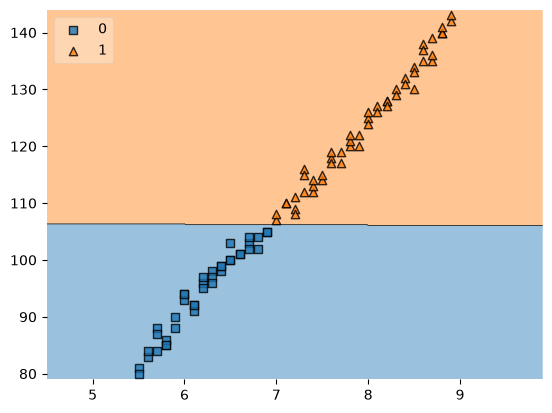

In [38]:
plot_decision_regions(x_train.values,y_train, clf=clff,legend=2)

### Lets try to save the model

In [40]:
import pickle

In [41]:
pickle.dump(clff,open('placement_predict_model.pkl','wb'))

### lets load the model

In [43]:

import pickle

with    open('placement_predict_model.pkl', 'rb') as f:
    model=pickle.load(f)

In [61]:
model.predict([[45,10]])


d:\ML\ml-env\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


array([0])